In [1]:
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid
import intake
import cf_xarray as cfxr
from access_nri_intake.experiment import use_datastore
from access_nri_intake.source import builders
import os
from xarray import SerializationWarning
import matplotlib.patches as mpatches

In [2]:
client = Client(n_workers=28)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/node.py:173: ResourceWarning: unclosed <socket.socket fd=62, family=2, type=1, proto=6, laddr=('0.0.0.0', 0)>
  if retries_left < 1:
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35857 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/35857/status,
Dashboard: /proxy/35857/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42219,Workers: 0
Dashboard: /proxy/35857/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37007,Total threads: 1
Dashboard: /proxy/43875/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:41273,


<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


In [3]:
# time period
start_time='2152-01-01'
end_time='2154-12-31'

In [4]:
expt_datastore = intake.open_esm_datastore(
    "./ssp585_th.json", 
    columns_with_iterables=[
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] # This is important
)


In [5]:
catalog = intake.cat.access_nri

In [6]:
## Get shelf mask
x_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/x_shelf.txt')
y_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/y_shelf.txt')

In [7]:
# read practical salinity
temp_th = expt_datastore.search(variable="temp",frequency = '1mon').to_dask()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [8]:
temp_th = temp_th.temp

In [9]:
# read practical salinity
salt_th = expt_datastore.search(variable="salt",frequency = '1mon').to_dask()
salt_th = salt_th.salt

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [10]:
catalog = intake.cat.access_nri

In [11]:
temp_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="temp",frequency = '1mon').to_dask()
temp_ctrl = temp_ctrl.temp

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})


In [12]:
salt_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="salt",frequency = '1mon').to_dask()
salt_ctrl = salt_ctrl.salt

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})


In [13]:
salt_ctrl = salt_ctrl.sel(time = slice(start_time,end_time))
salt_th = salt_th.sel(time = slice(start_time,end_time))

temp_ctrl = temp_ctrl.sel(time = slice(start_time,end_time))
temp_th = temp_th.sel(time = slice(start_time,end_time))

In [14]:
# practical salinity to absolute salinity
salt_ctrl = gsw.conversions.SA_from_SP(salt_ctrl,salt_ctrl.st_ocean,salt_ctrl.xt_ocean,salt_ctrl.yt_ocean)
salt_th = gsw.conversions.SA_from_SP(salt_th,salt_ctrl.st_ocean,salt_ctrl.xt_ocean,salt_ctrl.yt_ocean)

In [15]:
# conservative temp and absolute salinity to sigma1
rho_ctrl = gsw.density.sigma1(salt_ctrl, temp_ctrl-273.15)
rho_th = gsw.density.sigma1(salt_th, temp_th-273.15)

In [ ]:
# calculate the mean 
temp_ctrl = temp_ctrl.sel(yt_ocean = slice(-90,-40)).mean('time').load()
temp_th = temp_th.sel(yt_ocean = slice(-90,-40)).mean('time').load()

rho_ctrl = rho_ctrl.sel(yt_ocean = slice(-90,-40)).mean('time').load()
rho_th = rho_th.sel(yt_ocean = slice(-90,-40)).mean('time').load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 72.38 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
salt_ctrl = salt_ctrl.sel(yt_ocean = slice(-90,-40)).mean('time').load()
salt_th = salt_th.sel(yt_ocean = slice(-90,-40)).mean('time').load()

In [ ]:
# combine them into dataset
data = xr.Dataset({
    'Control': temp_ctrl.sel(st_ocean = slice(1.,8000.)),
    'Thermal': temp_th.sel(st_ocean = slice(1.,8000.)),
})

data_rho = xr.Dataset({
    'Control': rho_ctrl.sel(st_ocean = slice(1.,8000.)),
    'Thermal': rho_th.sel(st_ocean = slice(1.,8000.)),
})

data_salt = xr.Dataset({
    'Control': salt_ctrl.sel(st_ocean = slice(1.,8000.)),
    'Thermal': salt_th.sel(st_ocean = slice(1.,8000.)),
})

In [ ]:
levs_dens = [32.,32.2,32.3,32.5]

In [ ]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [ ]:
new_coord

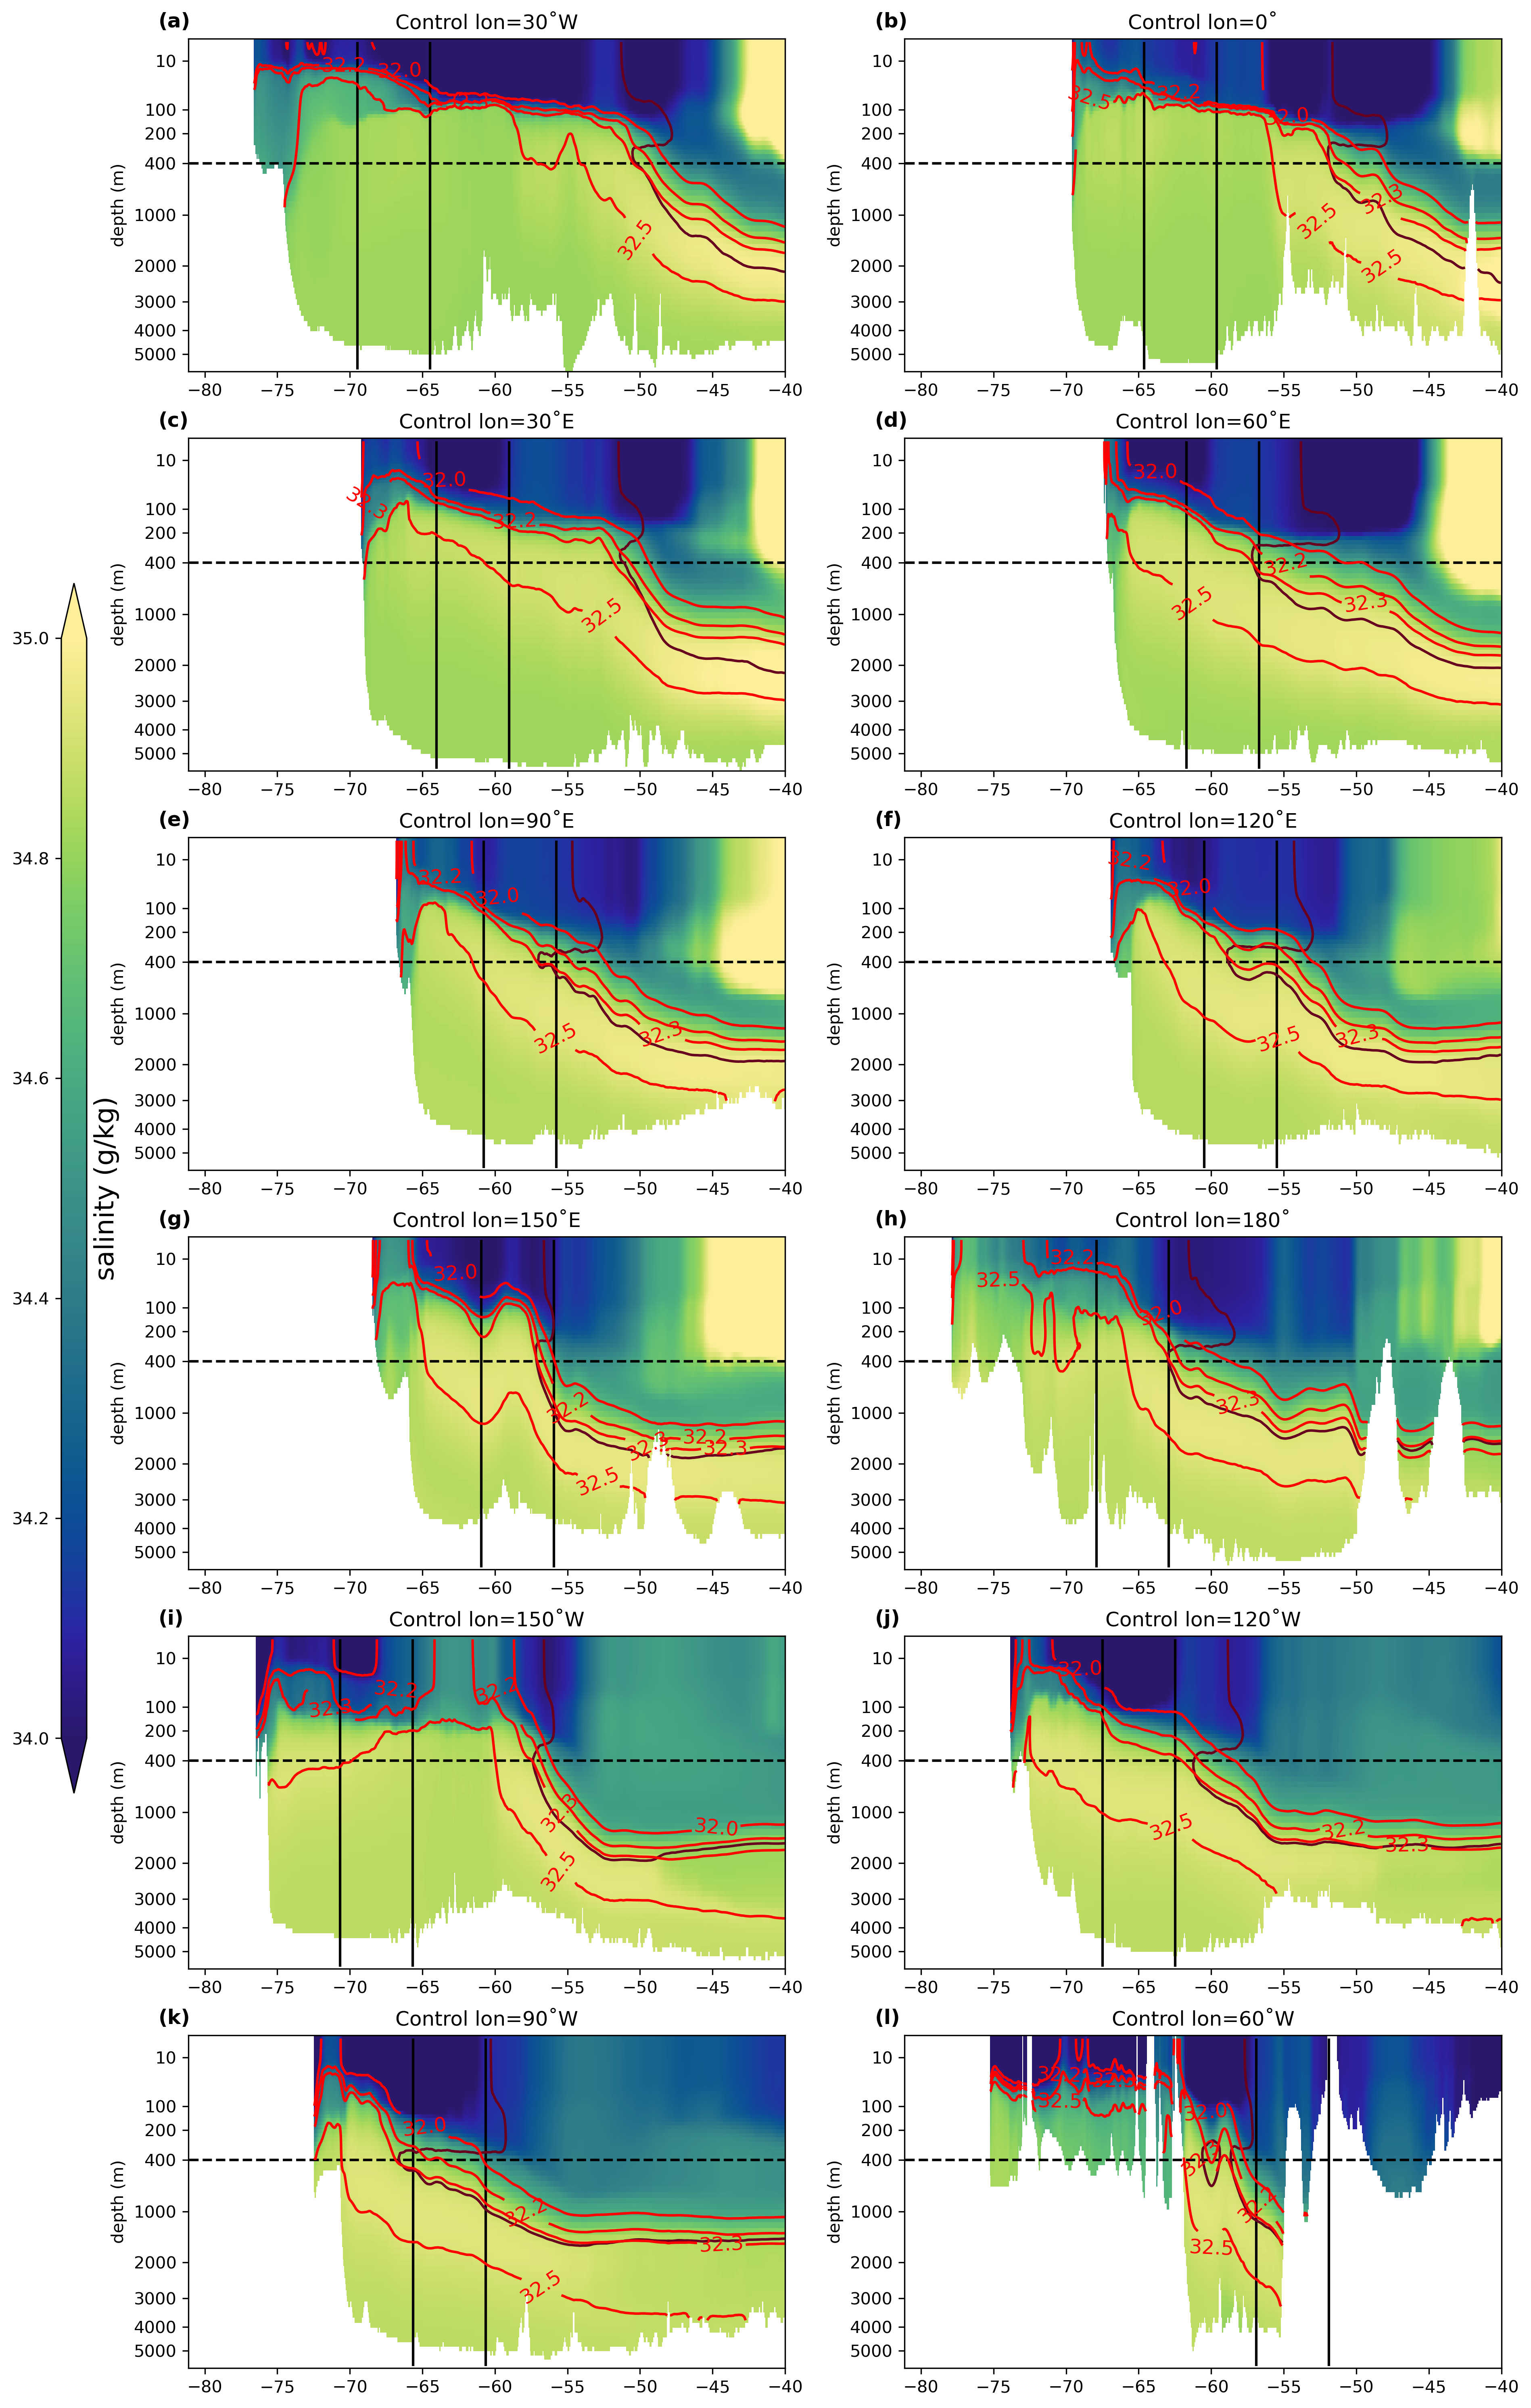

In [28]:
## plot the transects of T anomaly

fig = plt.figure(figsize=(14,25),dpi = 300)
for j in range(12):
    variable_name = 'Control'
    lon = [-30.,0,30.,60.,-270.,-240.,-210.,-180.,-150.,-120.,-90.,-60.][j]
    lon_1 = ['30˚W','0˚','30˚E','60˚E','90˚E','120˚E','150˚E','180˚','150˚W','120˚W','90˚W','60˚W']
    ax = plt.subplot(6,2,j+1)
    text = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)']
    p1 = (salt_ctrl.sel(st_ocean = slice(1.,8000.)).sel(xt_ocean = lon, method = 'nearest')).plot(vmin=34,vmax=35, cmap = cm.cm.haline,add_colorbar = False)
    (new_coord.sel(st_ocean = slice(1.,8000.)).sel(xt_ocean = lon, method = 'nearest')).plot.contour(levels = [5,10], colors='k',linestyles='-',linewidths=1.5,zorder=5)
    (temp_ctrl.sel(st_ocean = slice(1.,8000.)).sel(xt_ocean = lon, method = 'nearest')-273.15).plot.contour(levels = [2.8], linestyles='-',linewidths=1.5,zorder=5)
    c2 = plt.contour(rho_ctrl.yt_ocean.values,rho_ctrl[1:75,:,:].st_ocean.values,rho_ctrl.sel(st_ocean = slice(1.,8000.)).sel(xt_ocean = lon, method = 'nearest'),levels=levs_dens,colors='r',linestyles='-',linewidths=1.5,zorder=5)
    plt.clabel(c2,fontsize=12,inline=True,fmt='%1.1f',levels=levs_dens)
    plt.plot([-82,-40], [400,400], linestyle='--', color='k')
    def forward(x):
        return x**(1/3)
    def inverse(x):
        return x**3
    plt.gca().set_yscale('function', functions=(forward, inverse))
    plt.gca().invert_yaxis()
    ax.set(xlabel=None)
    plt.ylabel('depth (m)')
    ax.set_title(f'{variable_name}' + ' lon=' + f'{lon_1[j]}')
    ax.text(
        -0.05, 1.08, f'{text[j]}', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
    )
    plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
# colorbars
ax_cb1 = plt.axes([0.05, 0.3, 0.015, 0.4])
cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('salinity (g/kg)', fontsize = 16)
cb.ax.yaxis.set_ticks_position('left')

In [23]:
rho_ctrl

<xarray.DataArray 'salt' (st_ocean: 75, yt_ocean: 808, xt_ocean: 3600)> Size: 2GB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [30.71288101, 30.71238307, 30.71234127, ..., 30.71647081,
         30.71506211, 30.71379838],
        [30.70825876, 30.70851553, 30.70834557, ..., 30.7110478 ,
         30.70979073, 30.70873348],
        [30.70351026, 30.70387671, 30.70332289, ..., 30.70528795,
         30.70445747, 30.70366396]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 6kB -81.11 -81.07 -81.02 ... -40.11 -40.03
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03

In [ ]:
rho_ctrl.to_netcdf('/g/data/x77/hm1221/PhD_P1_data/rho_ctrl.nc')